# MATH 210 Introduction to Mathematical Computing

**March 11, 2026**

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Heun's method

Write a function called `odeHeun` which takes a function `f` (which represents the right hand side of a first order diferential equation), vector `t` of $t$ values, initial value `y0` (corresponding to initial time `t[0]`), and returns a 2D matrix with $t$ values in the first column and $y$ values given by Heun's method in the second column.

In [4]:
def odeHeun(f,t,y0):
    y = np.zeros(len(t))
    y[0] = y0
    for n in range(len(t) - 1):
        h = t[n+1] - t[n]
        k1 = f(t[n],y[n])
        k2 = f(t[n+1],y[n] + k1*h)
        y[n+1] = y[n] + (k1 + k2)/2*h
    return np.column_stack([t,y])

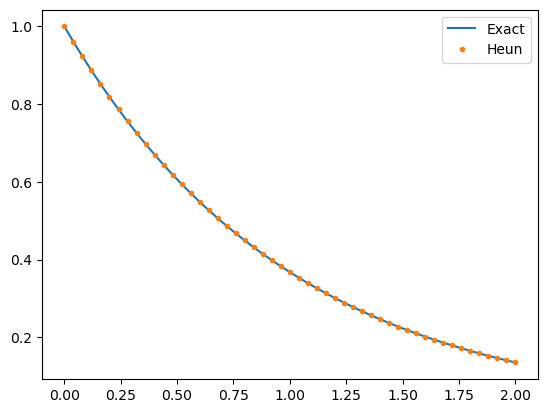

In [5]:
f = lambda t,y: -y
t = np.linspace(0,2,51)
y0 = 1
result = odeHeun(f,t,y0)
T = result[:,0]
Y = result[:,1]

texact = np.linspace(0,2,200)
yexact = np.exp(-texact)
plt.plot(texact,yexact,T,Y,'.')
plt.legend(['Exact','Heun'])
plt.show()

## Examples

(MATH 215, Example 2, Week 2) Find the unique solution of $y' + (2/x)y = \sin(x)$, $y(\pi)=0$. Use integrating factor to find the analytical solution:

$$
y(x) = -\cos(x) + \frac{2 \sin(x)}{x} + \frac{2 \cos(x)}{x^2} + \frac{2 - \pi^2}{x^2}
$$

Compare with numerical solution. Use $t$ as independent variable instead of $x$. Write equation in the form $y' = f(t,y)$.

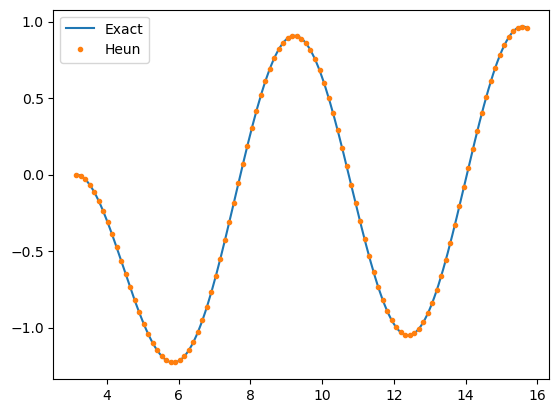

In [11]:
f = lambda t,y: np.sin(t) - 2/t*y
t = np.linspace(np.pi,5*np.pi,101)
y0 = 0
result = odeHeun(f,t,y0)
T = result[:,0]
Y = result[:,1]

texact = np.linspace(np.pi,5*np.pi,200)
yexact = lambda t: -np.cos(t) + 2*np.sin(t)/t + 2*np.cos(t)/t**2 + (2 - np.pi**2)/t**2
plt.plot(texact,yexact(texact),T,Y,'.')
plt.legend(['Exact','Heun'])
plt.show()